<div style="
    display: flex;
    justify-content: center;
    align-items: center;
    margin: 32px 0;
">
    <div style="
        background-color: #263D42;
        color: #FFFFFF;
        text-align: center;
        border-radius: 10px;
        padding: 20px 32px;
        max-width: 90%;
    ">
        <h2 style="
            font-size: 36px;
            font-family: 'Times New Roman', serif;
            font-weight: normal;
            margin: 0;
            line-height: 1.4;
        ">
            SCTEC — Projeto Avaliativo-Módulo 2<br>
            Visão Computacional e Machine Learning
        </h2>
        <p style="
            font-size: 18px;
            font-family: 'Times New Roman', serif;
            font-style: italic;
            margin-top: 12px;
            margin-bottom: 0;
            opacity: 0.9;
        ">
            Desenvolvido por Marcelo Yukio Takahashi
        </p>
    </div>
</div>

```
Pipeline preditivo de Visão Computacional e Machine Learning com foco na classificação de dígitos manuscritos e na comparação de desempenho entre os modelos clássicos e rede neural.
```

## Bibliotecas

In [1]:
# Importando as bibliotecas
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import cv2
from PIL import Image
# Biblioteca de modelos clássicos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
# Biblioteca de redes neurais
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Fase 01 - Carregamento e EDA

In [2]:
# Carregando o dataset MNIST do OpenML
print("Carregando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de carregar o dataset MNIST!")


Carregando o dataset MNIST...
Finalizou o processo de carregar o dataset MNIST!


In [3]:
# Separando Entradas (X) e Rótulos (y)
# Garantindo que os rótulos sejam do tipo inteiro
X, y = mnist.data, mnist.target.astype(int)

In [4]:
# Exemplo de um dígito do dataset
X[126]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,  23,  79, 192, 216, 216,
        91,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  13, 209, 252, 253,
       252, 252, 227,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 147, 209, 252,
       252, 244, 168,  80,  31,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 17

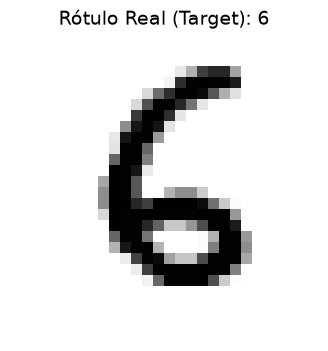

In [5]:
# Exibição do exemplo de um dígito do dataset
digito_exemplo = X[126]  # Selecionando o dígito na posição 126
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(digito_imagem, cmap='binary') # cmap='binary' mostra preto no branco
plt.title(f"Rótulo Real (Target): {y[126]}", fontsize=14)
plt.axis('off') # Oculta os eixos cartesianos
plt.show()

In [6]:
# Exibição da dimensionalidade dos dados
print(f"Dimensionalidade das Features (X): {X.shape}")
print(f"Dimensionalidade dos Rótulos (y): {y.shape}")

Dimensionalidade das Features (X): (70000, 784)
Dimensionalidade dos Rótulos (y): (70000,)


In [7]:
# Contagem de ocorrências por classe
classes, quantidades = np.unique(y, return_counts=True)

print("Distribuição dos dígitos no dataset:")
for classe, quantidade in zip(classes, quantidades):
    print(f"Dígito {classe}: {quantidade} imagens")


Distribuição dos dígitos no dataset:
Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


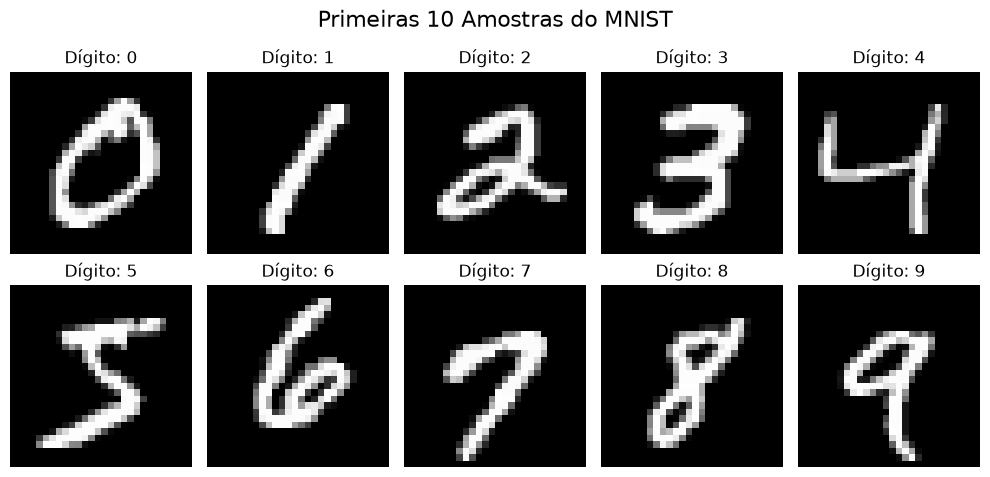

In [8]:
# Grade visual exibindo cada dígito do 0 ao 9
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()  # Achata a matriz de eixos para facilitar a iteração

for i in range(10):
    # Seleciona a primeira ocorrência do dígito i
    idx = np.where(y == i)[0][0]
    imagem = X[idx].reshape(28,28) # remodela a imagem para 28x28

    axes[i].imshow(imagem, cmap='gray')  # Exibe a imagem em escala de cinza
    axes[i].set_title(f"Dígito: {i}")
    axes[i].axis('off')  # Oculta os eixos
    
plt.suptitle("Primeiras 10 Amostras do MNIST", fontsize=16)
plt.tight_layout()
plt.show()

**Estrutura dos Dados e Representação Vetorial no MNIST**  
O dataset MNIST possui 70.000 imagens de números escritos à mão, representando os dígitos de 0 a 9.  
Cada imagem possui **28 × 28 pixels**, totalizando **784 pixels**. Os pixels possuem valores entre **0 e 255**, onde 0 representa o preto e 255 representa o branco. Os valores entre esses extremos representam diferentes tons de cinza.  
Como o dataset é armazenado em formato de tabela, cada imagem é transformada em uma única linha com 784 valores. Dessa forma, uma imagem que originalmente possui duas dimensões (28 × 28) passa a ser representada por um vetor com 784 posições.  
Por isso, a matriz `X` possui dimensão **70.000 × 784**: são 70.000 imagens e 784 valores para cada imagem.  
A variável `y` possui 70.000 valores, que representam o rótulo de cada imagem, indicando qual dígito está representado.  
Durante a análise, podemos transformar novamente os 784 valores de uma imagem em uma matriz 28 × 28 utilizando `reshape()`, permitindo visualizar a imagem normalmente.


## Fase 02 - Pré-processamento e divisão dos dados

In [9]:
# Dividimos 20% para Teste e 80% para Treino + Validação (X_temp)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [10]:
# Dos 80% restantes (X_temp), separar 12.5% para Validação.
# 12.5% de 80% equivale a exatamente 10% do total do dataset original (70% treino, 10% val, 20% teste).
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"Amostras de Treino: {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})")
print(f"Amostras de Validação: {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})")
print(f"Amostras de Teste: {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})")

Amostras de Treino: 49000 (70%)
Amostras de Validação: 7000 (10%)
Amostras de Teste: 14000 (20%)


In [11]:
# Normalização dos Pixels [0.0, 1.0]
# Instanciamos o MinMaxScaler
scaler = MinMaxScaler(feature_range=(0.0, 1.0))

In [12]:
# IMPORTANTE: Ajustar (fit) o scaler APENAS no conjunto de treino
X_train_norm = scaler.fit_transform(X_train)

In [13]:
# Transformar validação e teste usando os parâmetros aprendidos no treino
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

print("\nEscalonamento concluído:")
print(f"Valor mínimo no treino normalizado: {X_train_norm.min()}")
print(f"Valor máximo no treino normalizado: {X_train_norm.max()}")


Escalonamento concluído:
Valor mínimo no treino normalizado: 0.0
Valor máximo no treino normalizado: 1.0


**Divisão e normalização dos dados**  
Os dados foram divididos em três grupos: **70% para treinamento, 10% para validação e 20% para teste**. A divisão foi feita utilizando estratificação por classe, garantindo que os dígitos de 0 a 9 continuassem com uma distribuição semelhante nos três conjuntos.  
O conjunto de treinamento será utilizado para ensinar o modelo. O conjunto de validação será utilizado durante o desenvolvimento para comparar resultados e realizar ajustes. Já o conjunto de teste será mantido separado para uma avaliação final do modelo.  
Os valores dos pixels originalmente estão entre **0 e 255**. Esses valores foram normalizados dividindo cada pixel por 255, fazendo com que todos fiquem entre **0.0 e 1.0**.  
A normalização é importante porque facilita o trabalho dos modelos com os valores dos pixels. Em modelos lineares, trabalhar com valores em uma escala mais uniforme pode facilitar e estabilizar o processo de treinamento. Em modelos que utilizam distância, como o KNN, a normalização também ajuda a deixar os cálculos das distâncias em uma escala mais adequada.  
É importante destacar que a normalização não altera o desenho da imagem. Ela apenas modifica a escala dos valores utilizados para representar cada pixel.


## Fase 03 - Implementação e Treinamento dos 3 modelos

In [14]:
# Setar semente para reprodutibilidade no TensorFlow
tf.random.set_seed(42)

In [15]:
# ==========================================
# MODELO 1: K-Nearest Neighbors (KNN)
# ==========================================
print("--- Treinando Modelo 1: KNN ---")
# Justificativa de Hiperparâmetros:
# n_neighbors: quantidade de vizinhos considerados, 
#              significa que o modelo considera os 5 vizinhos mais próximos para fazer a previsão.
# weights: define como a influência dos vizinhos será calculada, "distance" 
#          faz com que os vizinhos mais próximos tenham maior influência na decisão
knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)

start_time = time.time()
knn_model.fit(X_train_norm, y_train)
print(f"KNN treinado em {time.time() - start_time:.2f} segundos.")

--- Treinando Modelo 1: KNN ---
KNN treinado em 0.34 segundos.


In [16]:
# ==========================================
# MODELO 2: Random Forest
# ==========================================
print("\n--- Treinando Modelo 2: Random Forest ---")
# Justificativa de Hiperparâmetros:
# - n_estimators=100: quantidade de árvore, 
#                    significa que o modelo utilizará 100 árvores de decisãos;
# - max_depth=20: profundidade máxima das árvores, 
#                 profundidade máxima de 20 níveis para as árvores
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)

start_time = time.time()
rf_model.fit(X_train_norm, y_train)
print(f"Random Forest treinada em {time.time() - start_time:.2f} segundos.")


--- Treinando Modelo 2: Random Forest ---
Random Forest treinada em 26.30 segundos.


In [17]:
# ==========================================
# MODELO 3: Rede Neural (MLP via Keras)
# ==========================================
print("\n--- Treinando Modelo 3: Rede Neural MLP ---")

# Definição da Arquitetura e Hiperparâmetros:
# - unidades (units=128): Significa que teremos uma camada intermediária com 128 neurônios.
# - activation='relu': utilizada para permitir que a rede aprenda relações mais complexas.
# - learning_rate=0.001 (Adam): Define o tamanho dos passos utilizados durante o aprendizado.
mlp_model = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu", name="Camada_Oculta_1"),
        layers.Dense(64, activation="relu", name="Camada_Oculta_2"),
        layers.Dense(
            10, activation="softmax", name="Camada_Saida"
        ),  # 10 classes
    ]
)

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.time()
history = mlp_model.fit(
    X_train_norm,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_norm, y_val),
    verbose=1,
)
print(f"MLP treinada em {time.time() - start_time:.2f} segundos.")


--- Treinando Modelo 3: Rede Neural MLP ---
Epoch 1/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9148 - loss: 0.2975 - val_accuracy: 0.9504 - val_loss: 0.1630
Epoch 2/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9625 - loss: 0.1249 - val_accuracy: 0.9657 - val_loss: 0.1140
Epoch 3/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9748 - loss: 0.0838 - val_accuracy: 0.9714 - val_loss: 0.0983
Epoch 4/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9813 - loss: 0.0613 - val_accuracy: 0.9716 - val_loss: 0.0941
Epoch 5/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9867 - loss: 0.0450 - val_accuracy: 0.9727 - val_loss: 0.0966
Epoch 6/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9897 - loss: 0.0351 - val_accuracy: 0.9737 - val_loss: 0.1030
Epoch 7/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9918 - loss: 0.0284 - val_accuracy: 0.9739 - val_loss: 0.1043
Epoch 8/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - 

**Explicação e Justificativa dos Hiperparâmetros**  
1. K-Nearest Neighbors (KNN):  
   *n_neighbors = 5*: Define a quantidade de pontos mais próximos a considerar. Valores muito baixos ($k=1$) tornam o algoritmo extremamente sensível a ruídos ou pixels com anomalias. Valores muito altos suavizam excessivamente as bordas de decisão entre dígitos parecidos (como $3$ e $8$).  
   *weights = 'distance'*: Atribui pesos inversamente proporcionais à distância de cada vizinho. Pixels mais semelhantes ao exemplo atual têm maior impacto no voto do que vizinhos mais distantes, o que compensa a alta dimensionalidade ($784$ dimensões).  

2. Random Forest:  
   *n_estimators = 100*: Define a quantidade de árvores de decisão na floresta. Aumentar o número de árvores reduz a variância do modelo geral e estabiliza a previsão por meio do princípio da votação por maioria.  
   *max_depth = 20*: Limita a profundidade máxima de crescimento de cada árvore. Árvores sem limite de profundidade tendem a memorizar perfeitamente o conjunto de treino (overfitting). Definir um teto de $20$ força o modelo a generalizar melhor nas folhas de decisão.  

3. Perceptron Multicamadas (MLP via TensorFlow/Keras):  
   *units = 128 / 64 e activation = 'relu'*: A arquitetura possui duas camadas ocultas. A função de ativação ReLU ($\max(0, x)$) introduz não linearidade e acelera drasticamente a convergência do gradiente descendente, evitando que os gradientes fiquem muito pequenos (vanishing gradient) em comparação a funções sigmóides ou $\tanh$.  
   *learning_rate = 0.001 (Otimizador Adam)*: A taxa de aprendizado controla a magnitude das atualizações dos pesos a cada batch. O otimizador Adam ajusta dinamicamente as taxas de aprendizado para cada parâmetro usando momentos de primeira e segunda ordem, garantindo convergência estável sem oscilações drásticas na função de perda.

## Fase 04 - Avaliação Comparativo de Desempenho

In [18]:
# Obtenção das predições no conjunto de TESTE
# KNN
y_pred_knn = knn_model.predict(X_test_norm)

# Random Forest
y_pred_rf = rf_model.predict(X_test_norm)

# MLP (Keras retorna probabilidades, convertemos com argmax)
y_pred_mlp_prob = mlp_model.predict(X_test_norm)
y_pred_mlp = np.argmax(y_pred_mlp_prob, axis=1)

modelos_preds = {
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "MLP (Rede Neural)": y_pred_mlp,
}

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [19]:
# Vamos calcular os tempos de treino de cada modelo para comparar performance vs. custo operacional
tempos_treino = {}

# KNN
inicio = time.perf_counter()
knn_model.fit(X_train, y_train)
fim = time.perf_counter()
tempos_treino["KNN"] = fim - inicio

# Random Forest
inicio = time.perf_counter()
rf_model.fit(X_train, y_train)
fim = time.perf_counter()
tempos_treino["Random Forest"] = fim - inicio

# MLP
inicio = time.perf_counter()
mlp_model.fit(X_train, y_train)
fim = time.perf_counter()
tempos_treino["MLP (Rede Neural)"] = fim - inicio

1532/1532 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9781 - loss: 10.2564


In [20]:
# Exibição dos tempos de treino de cada modelo
for modelo, tempo in tempos_treino.items():
    print(f"{modelo}: {tempo:.2f} segundos")

KNN: 0.02 segundos
Random Forest: 29.85 segundos
MLP (Rede Neural): 13.89 segundos


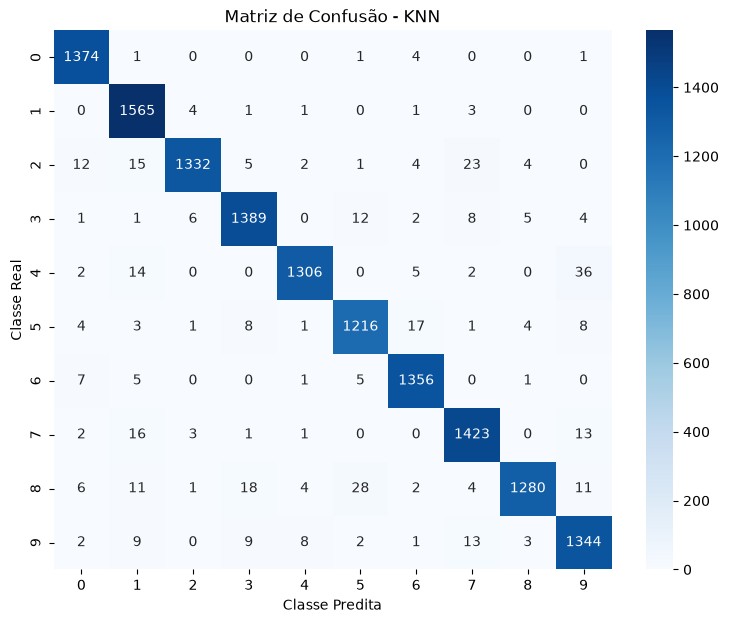

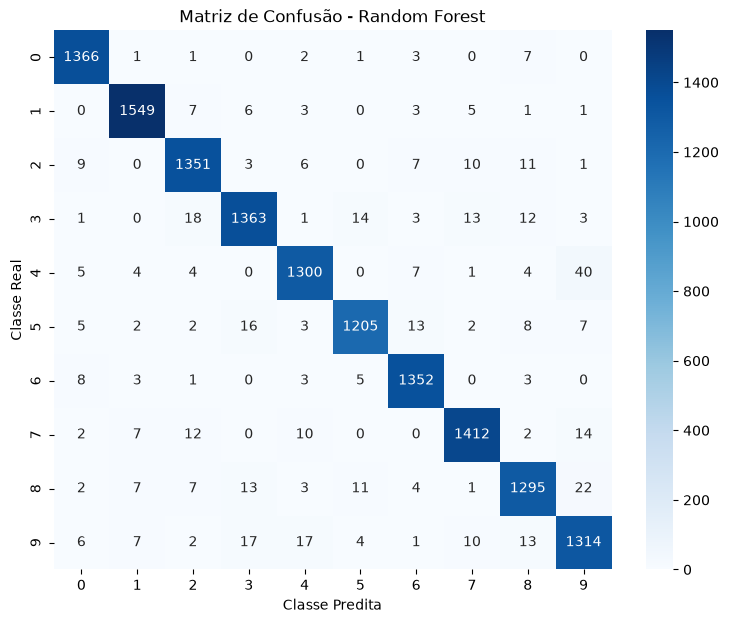

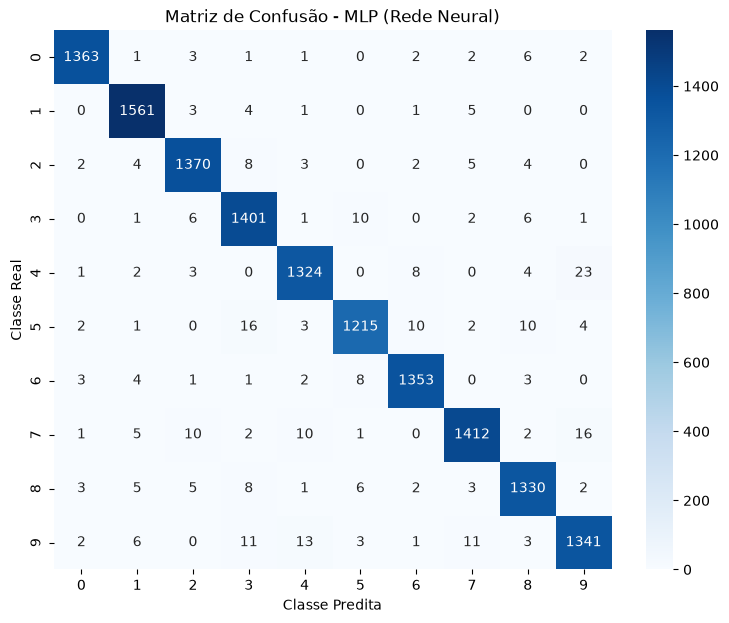

In [21]:
# Vamos mostrar as Matrizes de Confusão (10 x 10) com Heatmap de cada modelo
def mostrar_matriz_confusao(y_true, y_pred, nome_modelo):
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(9, 7))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=range(10),
        yticklabels=range(10)
    )
    
    plt.title(f"Matriz de Confusão - {nome_modelo}")
    plt.xlabel("Classe Predita")
    plt.ylabel("Classe Real")
    plt.show()

for nome, pred in modelos_preds.items():
    mostrar_matriz_confusao(y_test, pred, nome)

In [22]:
# Para facilitar a análise dos erros, vamos criar uma função que retorna as maiores confusões de cada modelo
def maiores_confusoes(y_true, y_pred, quantidade=5):
    cm = confusion_matrix(y_true, y_pred)
    erros = []
    
    for i in range(10):
        for j in range(10):
            if i != j:
                erros.append((cm[i, j], i, j))
    erros.sort(reverse=True)
    
    return erros[:quantidade]

for nome, pred in modelos_preds.items():  
    print(f"\nMaiores confusões - {nome}")
    for quantidade, real, previsto in maiores_confusoes(y_test, pred):
        print(
            f"Real: {real} → Predito: {previsto} "
            f"({quantidade} casos)"
        )


Maiores confusões - KNN
Real: 4 → Predito: 9 (36 casos)
Real: 8 → Predito: 5 (28 casos)
Real: 2 → Predito: 7 (23 casos)
Real: 8 → Predito: 3 (18 casos)
Real: 5 → Predito: 6 (17 casos)

Maiores confusões - Random Forest
Real: 4 → Predito: 9 (40 casos)
Real: 8 → Predito: 9 (22 casos)
Real: 3 → Predito: 2 (18 casos)
Real: 9 → Predito: 4 (17 casos)
Real: 9 → Predito: 3 (17 casos)

Maiores confusões - MLP (Rede Neural)
Real: 4 → Predito: 9 (23 casos)
Real: 7 → Predito: 9 (16 casos)
Real: 5 → Predito: 3 (16 casos)
Real: 9 → Predito: 4 (13 casos)
Real: 9 → Predito: 7 (11 casos)


In [23]:
# Vamos calcular as métricas de avaliação para cada modelo
resultados = []

for nome, pred in modelos_preds.items():
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(
        y_test,
        pred,
        average='weighted'
    )
    recall = recall_score(
        y_test,
        pred,
        average='weighted'
    )
    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )
    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Tempo de Treino (s)": tempos_treino[nome]
    })
# Transformando os resultados em um DataFrame para melhor visualização
df_resultados = pd.DataFrame(resultados)
df_resultados


,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo de Treino (s)
0,KNN,0.970357,0.970664,0.970357,0.970323,0.017331
1,Random Forest,0.964786,0.964787,0.964786,0.964760,29.854810
2,MLP (Rede Neural),0.976429,0.976448,0.976429,0.976419,13.889725


In [24]:
# Usando o classification_report do sklearn para comparar as métricas de cada modelo
for nome, pred in modelos_preds.items():
    print(f"\n{'=' * 60}")
    print(f"Classification Report - {nome}")
    print(f"{'=' * 60}")   
    print(
        classification_report(
            y_test,
            pred,
            digits=4
        )
    )


Classification Report - KNN
              precision    recall  f1-score   support

           0     0.9745    0.9949    0.9846      1381
           1     0.9543    0.9937    0.9736      1575
           2     0.9889    0.9528    0.9705      1398
           3     0.9706    0.9727    0.9717      1428
           4     0.9864    0.9568    0.9714      1365
           5     0.9613    0.9628    0.9620      1263
           6     0.9741    0.9862    0.9801      1375
           7     0.9634    0.9753    0.9693      1459
           8     0.9869    0.9377    0.9617      1365
           9     0.9485    0.9662    0.9573      1391

    accuracy                         0.9704     14000
   macro avg     0.9709    0.9699    0.9702     14000
weighted avg     0.9707    0.9704    0.9703     14000


Classification Report - Random Forest
              precision    recall  f1-score   support

           0     0.9729    0.9891    0.9810      1381
           1     0.9804    0.9835    0.9819      1575
          

In [25]:
# Vamos identificar o melhor modelo com base na métrica F1-Score
melhor_modelo = df_resultados.loc[
    df_resultados["F1-Score"].idxmax(),
    "Modelo"
]

print("Melhor modelo:", melhor_modelo)

Melhor modelo: MLP (Rede Neural)


In [26]:
# Vamos identificar o modelo com melhor acurácia (Accuracy)
melhor_accuracy = df_resultados.loc[
    df_resultados["Accuracy"].idxmax(),
    "Modelo"
]

print("Maior Accuracy:", melhor_accuracy)

Maior Accuracy: MLP (Rede Neural)


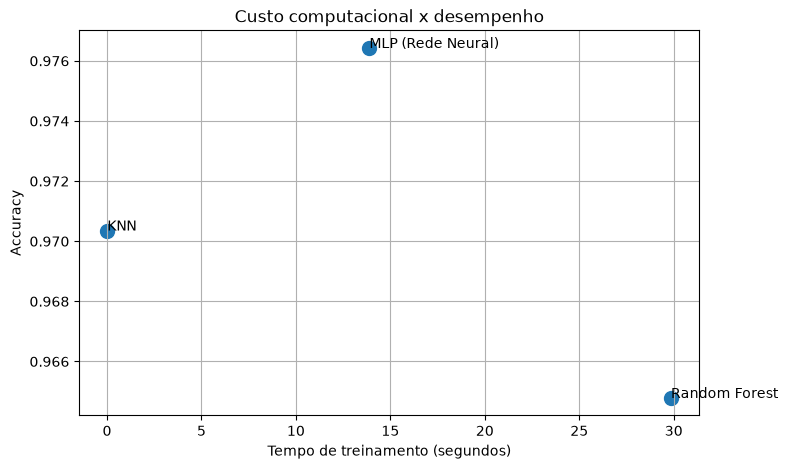

In [27]:
# Visulização do custo benefício (tempo de treino x acurácia) dos modelos
plt.figure(figsize=(8, 5))

plt.scatter(
    df_resultados["Tempo de Treino (s)"],
    df_resultados["Accuracy"],
    s=100
)

for _, linha in df_resultados.iterrows():
    plt.annotate(
        linha["Modelo"],
        (
            linha["Tempo de Treino (s)"],
            linha["Accuracy"]
        )
    )

plt.xlabel("Tempo de treinamento (segundos)")
plt.ylabel("Accuracy")
plt.title("Custo computacional x desempenho")
plt.grid(True)

plt.show()

**Conclusão da avaliação comparativa**  
Após a avaliação dos três modelos utilizando o conjunto de teste independente, foi possível comparar o desempenho de cada abordagem.  
O modelo **MLP (Rede Neural)** apresentou a melhor performance geral, considerando principalmente o **F1-Score de 0.98** e a **Acuracidade de 0.98**. Os resultados mostram que esse modelo conseguiu realizar a classificação dos dígitos com melhor desempenho entre os modelos avaliados.

Na análise das matrizes de confusão, a maior dificuldade encontrada foi a distinção entre o dígito **4** e o dígito **9**, com mais de **36** casos nos três modelos. Isso mostra que algumas imagens possuem características visuais semelhantes, dificultando a classificação correta.

Em relação ao custo computacional, o modelo **KNN** apresentou o menor tempo de treinamento, enquanto o modelo **Random Forest** apresentou o maior tempo, sendo que o **KNN** mostrou uma acuracidade superior ao **Random Forest**. A **MLP (Rede Neural)** apresentou o melhor desempenho em acuracidade com o tempo de treinamento entre o KNN e o Random Forest, por isso o consideramos o mais interessante para este projeto, pois conseguiu alcançar **F1-Score de 0.98** e a **Acuracidade de 0.98** utilizando um custo computacional **moderado**.

De forma geral, os resultados mostram que a escolha de um modelo não deve considerar apenas a Acuracidade. Também é importante observar as demais métricas, os tipos de erros cometidos e o tempo necessário para realizar o treinamento.


## Fase 05 - Teste de capacidade dos modelos

### Fase 05.1 - Treinamento sem classes

In [28]:
# ==========================================
# FASE 5.1: Treinamento sem as Classes 1 e 5
# ==========================================
classes_ocultadas = [1, 5]
print(f"--- FASE 5.1: Ocultando as classes {classes_ocultadas} do Treino ---")

# Criar máscara booleana para filtrar o conjunto de treino
mascara_treino = ~np.isin(y_train, classes_ocultadas)

X_train_ood = X_train_norm[mascara_treino]
y_train_ood = y_train[mascara_treino]

print(f"Amostras de treino originais: {X_train_norm.shape[0]}")
print(f"Amostras de treino OOD (sem 1 e 5): {X_train_ood.shape[0]}")

# Reconstruir e treinar a MLP OOD
mlp_ood = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),  # Mantém 10 saídas
    ]
)

mlp_ood.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mlp_ood.fit(X_train_ood, y_train_ood, epochs=12, batch_size=64, verbose=0)
print("Modelo OOD treinado com sucesso!")

--- FASE 5.1: Ocultando as classes [1, 5] do Treino ---
Amostras de treino originais: 49000
Amostras de treino OOD (sem 1 e 5): 39067
Modelo OOD treinado com sucesso!


### Fase 05.2 - Teste sem as classes


--- FASE 5.2: Avaliando apenas em amostras das classes 1 e 5 ---
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


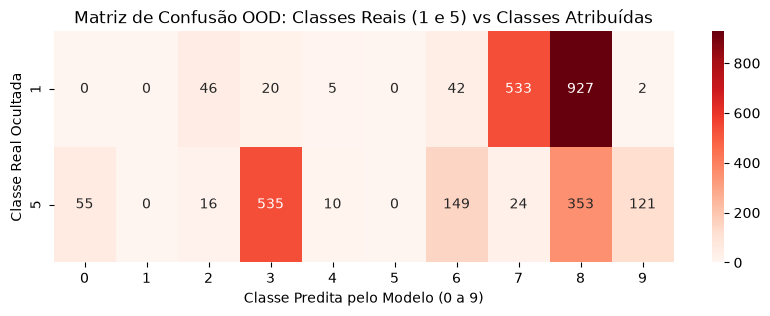

Confiança média ao classificar objetos nunca vistos: 88.55%


In [29]:
# ==========================================
# FASE 5.2: Teste de Generalização Extrema
# ==========================================
print("\n--- FASE 5.2: Avaliando apenas em amostras das classes 1 e 5 ---")

# Criar máscara para o conjunto de teste contendo APENAS 1 e 5
mascara_teste_ood = np.isin(y_test, classes_ocultadas)
X_test_only_15 = X_test_norm[mascara_teste_ood]
y_test_only_15 = y_test[mascara_teste_ood]

# Predições de probabilidades e classes
probabilidades_ood = mlp_ood.predict(X_test_only_15)
predicoes_ood = np.argmax(probabilidades_ood, axis=1)

# Matriz de Confusão para o teste OOD (Linhas: 1 e 5 | Colunas: 0 a 9)
cm_ood = confusion_matrix(
    y_test_only_15, predicoes_ood, labels=list(range(10))
)
# Filtrando apenas as linhas das classes ocultadas para exibição limpa
cm_ood_filtrada = cm_ood[classes_ocultadas, :]

plt.figure(figsize=(10, 3))
sns.heatmap(
    cm_ood_filtrada,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=list(range(10)),
    yticklabels=classes_ocultadas,
)
plt.title("Matriz de Confusão OOD: Classes Reais (1 e 5) vs Classes Atribuídas")
plt.xlabel("Classe Predita pelo Modelo (0 a 9)")
plt.ylabel("Classe Real Ocultada")
plt.show()

# Análise de Confiança
confiancas = np.max(probabilidades_ood, axis=1)
print(f"Confiança média ao classificar objetos nunca vistos: {confiancas.mean():.2%}")

In [30]:
print("Classes previstas pelo modelo:")
print(
    pd.Series(probabilidades_ood.argmax(axis=1))
    .value_counts()
    .sort_index()
)

Classes previstas pelo modelo:
0      55
2      62
3     555
4      15
6     191
7     557
8    1280
9     123
Name: count, dtype: int64


**Como o classificador reage ao ser forçado a classificar algo que nunca viu?**    
Na primeira etapa, os dígitos **1 e 5** foram completamente retirados do conjunto de treinamento. Dessa forma, o modelo não teve contato com essas classes durante o aprendizado.  
Numa segunda etapa, o modelo foi apresentado somente a imagens dos dígitos que não conhecia (1 e 5). Como essas classes não faziam parte do treinamento, o modelo não tinha uma opção para responder "não sei". Em vez disso, precisou escolher uma das classes que conhecia.  
Foi observado que os dígitos desconhecidos foram atribuídos principalmente às classes **8, 3 e 7**, mostrando que o modelo tentou relacionar as imagens desconhecidas com os padrões que já havia aprendido.

Esse resultado demonstra um ponto importante dos modelos de Machine Learning: uma previsão com alta probabilidade não significa necessariamente que a resposta esteja correta. O modelo pode apresentar uma confiança elevada mesmo quando está diante de uma situação que não conhece. Esse comportamento é relacionado ao conceito de **overconfidence**, ou falsa certeza.

Assim, os testes realizados nesta fase mostram que para avaliar um modelo é importante observar como ele se comporta diante de classes desconhecidas e de dados diferentes daqueles utilizados durante o treinamento.


### Fase 05.3 - Teste com imagem própria

In [31]:
# ============================================================
# FASE 5.3: Teste de Generalização Extrema com Imagem Própria
# ============================================================

def preprocessar_imagem_propria(caminho_imagem):
    # 1. Carregar imagem e converter para escala de cinza
    img_pil = Image.open(caminho_imagem).convert("L")
    img_np = np.array(img_pil)

    # 2. Inversão de cores se o fundo for claro (traço escuro no papel)
    # No MNIST, fundo é 0 (preto) e traço é 255 (branco)
    if img_np.mean() > 127:
        img_np = 255 - img_np

    # Binarização simples para encontrar contornos e Bounding Box
    _, thresh = cv2.threshold(img_np, 50, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        # Encontrar caixa delimitadora do traço
        x, y, w, h = cv2.boundingRect(coords)
        recorte = img_np[y : y + h, x : x + w]

        # Criar uma imagem quadrada mantendo a proporção
        max_dim = max(w, h)
        imagem_quadrada = np.zeros((max_dim, max_dim), dtype=np.uint8)

        # Centralizar o recorte na imagem quadrada
        off_x = (max_dim - w) // 2
        off_y = (max_dim - h) // 2
        imagem_quadrada[off_y : off_y + h, off_x : off_x + w] = recorte
    else:
        imagem_quadrada = img_np

    # 3. Redimensionamento para 20x20 e preenchimento com borda para 28x28 (padrão MNIST)
    img_resized = cv2.resize(
        imagem_quadrada, (20, 20), interpolation=cv2.INTER_AREA
    )
    img_28x28 = np.pad(img_resized, pad_width=4, mode="constant", constant_values=0)

    # 4. Normalização para o intervalo [0.0, 1.0]
    img_norm = img_28x28.astype("float32") / 255.0

    return img_norm, img_28x28

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


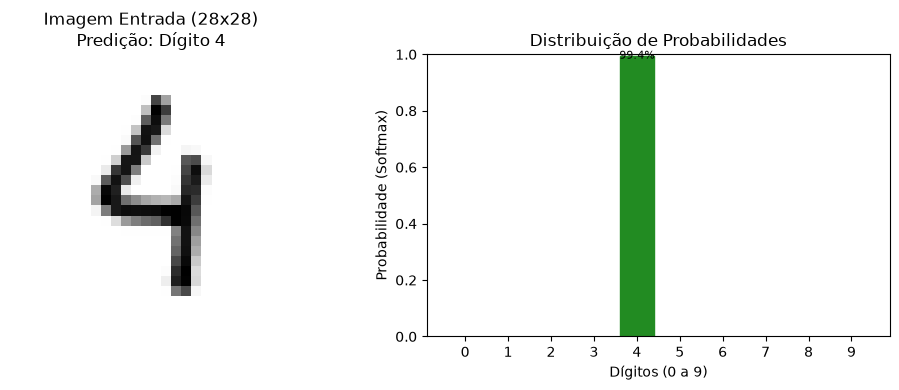

In [32]:
# --- Execução da Inferência com Imagem Própria ---
# Substitua 'meu_digito.png' pelo caminho do seu arquivo local
caminho = "data/4.png"

try:
    img_processada_vetor, img_28x28 = preprocessar_imagem_propria(caminho)

    # Reformatação para o formato aceito pelo modelo (1, 784)
    entrada_modelo = img_processada_vetor.reshape(1, 784)

    # Predição com o modelo original (MLP treinado com todas as classes)
    probs = mlp_model.predict(entrada_modelo)[0]
    classe_predita = np.argmax(probs)

    # Visualização: Imagem Processada ao lado do Gráfico de Probabilidades
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Ax 1: Imagem Processada
    ax1.imshow(img_28x28, cmap="binary")
    ax1.set_title(
        f"Imagem Entrada (28x28)\nPredição: Dígito {classe_predita}"
    )
    ax1.axis("off")

    # Ax 2: Gráfico de Probabilidades
    barras = ax2.bar(range(10), probs, color="skyblue")
    barras[classe_predita].set_color("forestgreen")
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Dígitos (0 a 9)")
    ax2.set_ylabel("Probabilidade (Softmax)")
    ax2.set_title("Distribuição de Probabilidades")
    ax2.set_ylim(0, 1.0)

    for bar in barras:
        yval = bar.get_height()
        if yval > 0.05:
            ax2.text(
                bar.get_x() + bar.get_width() / 2.0,
                yval + 0.02,
                f"{yval:.1%}",
                ha="center",
                va="top",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(
        f"Arquivo '{caminho}' não encontrado. Salve sua imagem na mesma pasta do código e tente novamente."
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


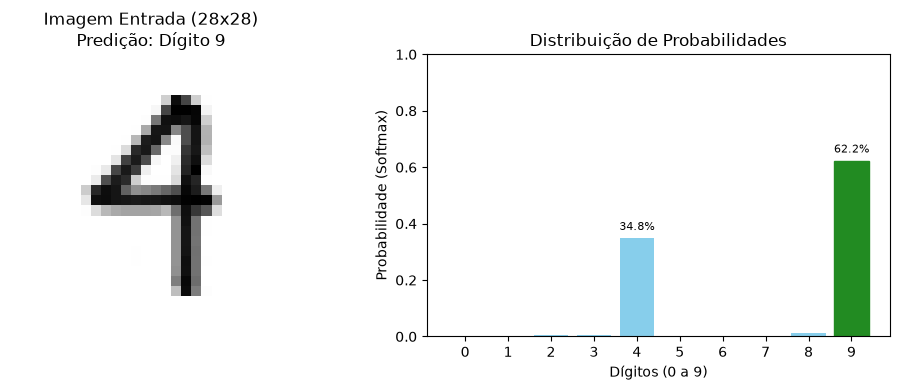

In [33]:
# --- Execução da Inferência com Imagem Própria ---
# Substitua 'meu_digito.png' pelo caminho do seu arquivo local
caminho = "data/4a.png"

try:
    img_processada_vetor, img_28x28 = preprocessar_imagem_propria(caminho)

    # Reformatação para o formato aceito pelo modelo (1, 784)
    entrada_modelo = img_processada_vetor.reshape(1, 784)

    # Predição com o modelo original (MLP treinado com todas as classes)
    probs = mlp_model.predict(entrada_modelo)[0]
    classe_predita = np.argmax(probs)

    # Visualização: Imagem Processada ao lado do Gráfico de Probabilidades
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Ax 1: Imagem Processada
    ax1.imshow(img_28x28, cmap="binary")
    ax1.set_title(
        f"Imagem Entrada (28x28)\nPredição: Dígito {classe_predita}"
    )
    ax1.axis("off")

    # Ax 2: Gráfico de Probabilidades
    barras = ax2.bar(range(10), probs, color="skyblue")
    barras[classe_predita].set_color("forestgreen")
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Dígitos (0 a 9)")
    ax2.set_ylabel("Probabilidade (Softmax)")
    ax2.set_title("Distribuição de Probabilidades")
    ax2.set_ylim(0, 1.0)

    for bar in barras:
        yval = bar.get_height()
        if yval > 0.05:
            ax2.text(
                bar.get_x() + bar.get_width() / 2.0,
                yval + 0.02,
                f"{yval:.1%}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(
        f"Arquivo '{caminho}' não encontrado. Salve sua imagem na mesma pasta do código e tente novamente."
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


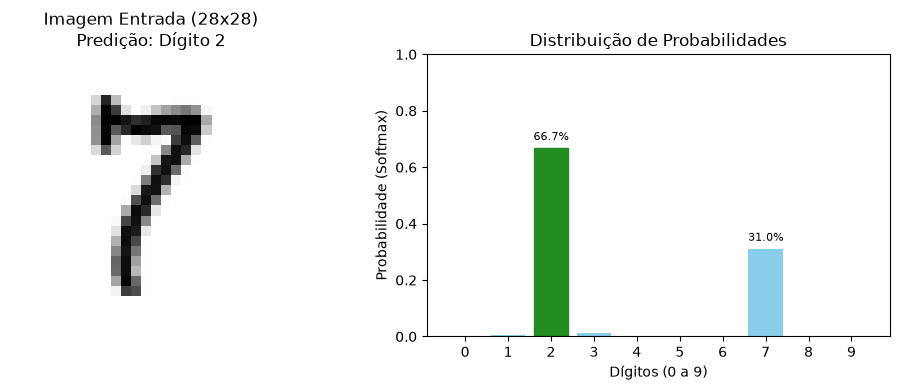

In [34]:
# --- Execução da Inferência com Imagem Própria ---
# Substitua 'meu_digito.png' pelo caminho do seu arquivo local
caminho = "data/7.png"

try:
    img_processada_vetor, img_28x28 = preprocessar_imagem_propria(caminho)

    # Reformatação para o formato aceito pelo modelo (1, 784)
    entrada_modelo = img_processada_vetor.reshape(1, 784)

    # Predição com o modelo original (MLP treinado com todas as classes)
    probs = mlp_model.predict(entrada_modelo)[0]
    classe_predita = np.argmax(probs)

    # Visualização: Imagem Processada ao lado do Gráfico de Probabilidades
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Ax 1: Imagem Processada
    ax1.imshow(img_28x28, cmap="binary")
    ax1.set_title(
        f"Imagem Entrada (28x28)\nPredição: Dígito {classe_predita}"
    )
    ax1.axis("off")

    # Ax 2: Gráfico de Probabilidades
    barras = ax2.bar(range(10), probs, color="skyblue")
    barras[classe_predita].set_color("forestgreen")
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Dígitos (0 a 9)")
    ax2.set_ylabel("Probabilidade (Softmax)")
    ax2.set_title("Distribuição de Probabilidades")
    ax2.set_ylim(0, 1.0)

    for bar in barras:
        yval = bar.get_height()
        if yval > 0.05:
            ax2.text(
                bar.get_x() + bar.get_width() / 2.0,
                yval + 0.02,
                f"{yval:.1%}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(
        f"Arquivo '{caminho}' não encontrado. Salve sua imagem na mesma pasta do código e tente novamente."
    )